# Exploratory Data Analysis (EDA)

Investigating the datasets one by one and altogether

## Importing libraries

In [1]:
# Importing packages
import glob
import os
import pandas as pd
import matplotlib.pyplot as plt
import pandas as pd

# import
import sys
sys.path.append("..")
from fuzzy import helpers, charts

## Loading processed data from the ETL pipeline

In [2]:
# Get all datasets
all_df = helpers.all_csv_to_df("../data/processed_data")

Importing:
products.csv: 4 rows, 9 columns
orders.csv: 32313 rows, 14 columns
website_sessions.csv: 472871 rows, 15 columns
order_item_refunds.csv: 1731 rows, 11 columns
order_items.csv: 40025 rows, 13 columns
website_pageviews.csv: 1188124 rows, 10 columns


In [3]:
# Get independent dataframes
refunds_df, order_item_df, orders_df, products_df, pageview_df, session_df = all_df["order_item_refunds.csv"],all_df["order_items.csv"], all_df["orders.csv"],all_df["products.csv"], all_df["website_pageviews.csv"], all_df["website_sessions.csv"]

## Orders

In [4]:
orders_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32313 entries, 0 to 32312
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   order_id            32313 non-null  int64         
 1   created_at          32313 non-null  datetime64[us]
 2   website_session_id  32313 non-null  int64         
 3   user_id             32313 non-null  int64         
 4   primary_product_id  32313 non-null  int64         
 5   items_purchased     32313 non-null  int64         
 6   price_usd           32313 non-null  float64       
 7   cogs_usd            32313 non-null  float64       
 8   hour                32313 non-null  int64         
 9   week_day            32313 non-null  int64         
 10  week_day_name       32313 non-null  str           
 11  day                 32313 non-null  int64         
 12  month               32313 non-null  int64         
 13  month_name          32313 non-null  str           
dtypes

In [5]:
orders_df.describe()

,order_id,created_at,website_session_id,user_id,primary_product_id,items_purchased,price_usd,cogs_usd,hour,week_day,day,month
count,32313.000000,32313,32313.000000,32313.000000,32313.000000,32313.000000,32313.000000,32313.000000,32313.000000,32313.000000,32313.000000,32313.000000
mean,16157.000000,2014-04-14 03:01:01.276823,258292.288707,215691.622629,1.392474,1.238666,59.991636,22.355406,13.006870,2.525826,15.723145,6.583326
min,1.000000,2012-03-19 10:42:46,20.000000,13.000000,1.000000,1.000000,29.990000,9.490000,0.000000,0.000000,1.000000,1.000000
25%,8079.000000,2013-10-30 14:30:35,144828.000000,124135.000000,1.000000,1.000000,49.990000,19.490000,10.000000,1.000000,8.000000,3.000000
50%,16157.000000,2014-06-11 14:27:02,263554.000000,221461.000000,1.000000,1.000000,49.990000,19.490000,13.000000,2.000000,16.000000,7.000000
75%,24235.000000,2014-11-28 10:53:48,374799.000000,310542.000000,2.000000,1.000000,59.990000,22.490000,17.000000,4.000000,23.000000,10.000000
max,32313.000000,2015-03-19 05:38:31,472818.000000,394273.000000,4.000000,2.000000,109.980000,41.980000,23.000000,6.000000,31.000000,12.000000
std,9328.103961,NaN,132427.649842,108402.203189,0.732277,0.426274,17.808771,6.238621,5.761418,1.829248,8.801308,3.806707


- Majority of customers are only buying 1 item each time they visit the store -> The company should incorporate upsale strategy to drive sales

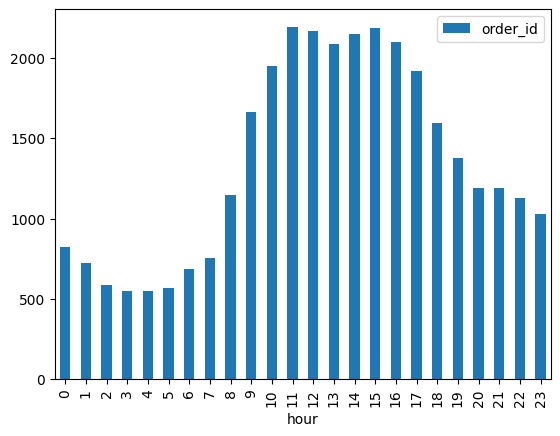

In [ ]:
# Bar chart to examine orders volume during a day
charts.data_over_time(orders_df["order_id"],orders_df["hour"])

- Sales peaked at 11AM and 4PM
- Orders are often placed during the 11AM to 4PM period
-> Insights for time to run ads or promo during the day

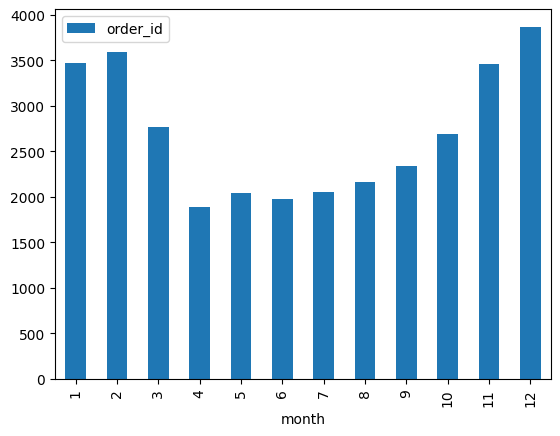

In [ ]:
# Bar chart to examine orders volume during a year
charts.data_over_time(orders_df["order_id"],orders_df["month"])